In [ ]:
import pandas as pd

# Load the provided datasets
file_path_1 = "/content/drive/MyDrive/Projects/Blockhouse/Data/AAPL_Quotes_Data.csv"
file_path_2 = "/content/drive/MyDrive/Projects/Blockhouse/Data/merged_bid_ask_ohlcv_data (1).csv"

# Loading the datasets into pandas DataFrames
aapl_quotes_data = pd.read_csv(file_path_1)
merged_bid_ask_data = pd.read_csv(file_path_2)


In [ ]:

# Display the first few rows of each dataset to understand their structure
aapl_quotes_data_head = aapl_quotes_data.head()
merged_bid_ask_data_head = merged_bid_ask_data.head()



In [ ]:
merged_bid_ask_data.head()

,timestamp,bid_price_1,bid_price_2,bid_price_3,bid_price_4,bid_price_5,bid_size_1,bid_size_2,bid_size_3,bid_size_4,...,publisher_id,instrument_id,open,high,low,close,volume,symbol,log_return,volatility
0,2023-09-12 13:30:00+00:00,179.66,179.66,179.66,179.66,179.66,27600.0,30000.0,23100.0,23100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-09-12 13:31:00+00:00,179.89,179.89,179.89,179.89,179.89,21200.0,900.0,1200.0,20300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-09-12 13:32:00+00:00,180.12,180.12,180.12,180.12,180.11,10000.0,30000.0,20000.0,30000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-09-12 13:33:00+00:00,179.99,179.99,179.99,179.99,179.99,17400.0,19700.0,9700.0,19700.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-09-12 13:34:00+00:00,179.78,179.78,179.78,179.78,179.78,10000.0,10000.0,12100.0,10600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
merged_bid_ask_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100964 entries, 0 to 100963
Data columns (total 32 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      100964 non-null  object 
 1   bid_price_1    100964 non-null  float64
 2   bid_price_2    100931 non-null  float64
 3   bid_price_3    100879 non-null  float64
 4   bid_price_4    100825 non-null  float64
 5   bid_price_5    100769 non-null  float64
 6   bid_size_1     100964 non-null  float64
 7   bid_size_2     100931 non-null  float64
 8   bid_size_3     100879 non-null  float64
 9   bid_size_4     100825 non-null  float64
 10  bid_size_5     100769 non-null  float64
 11  ask_price_1    100964 non-null  float64
 12  ask_price_2    100931 non-null  float64
 13  ask_price_3    100879 non-null  float64
 14  ask_price_4    100825 non-null  float64
 15  ask_price_5    100769 non-null  float64
 16  ask_size_1     100964 non-null  float64
 17  ask_size_2     100931 non-nul

In [ ]:
# Check for missing values in the merged_bid_ask_ohlcv_data.csv dataset
missing_values_summary = merged_bid_ask_data.isnull().sum()

# Display the summary of missing values for each column
missing_values_summary


,0
timestamp,0
bid_price_1,0
bid_price_2,33
bid_price_3,85
bid_price_4,139
bid_price_5,195
bid_size_1,0
bid_size_2,33
bid_size_3,85
bid_size_4,139


In [ ]:
# Drop the remaining rows with missing values in the OHLCV, log_return, and volatility columns
merged_bid_ask_data.dropna(inplace=True)

# Verify that there are no more missing values
missing_values_final_check = merged_bid_ask_data.isnull().sum()

# Display the final summary of missing values after dropping rows
missing_values_final_check


,0
timestamp,0
bid_price_1,0
bid_price_2,0
bid_price_3,0
bid_price_4,0
bid_price_5,0
bid_size_1,0
bid_size_2,0
bid_size_3,0
bid_size_4,0


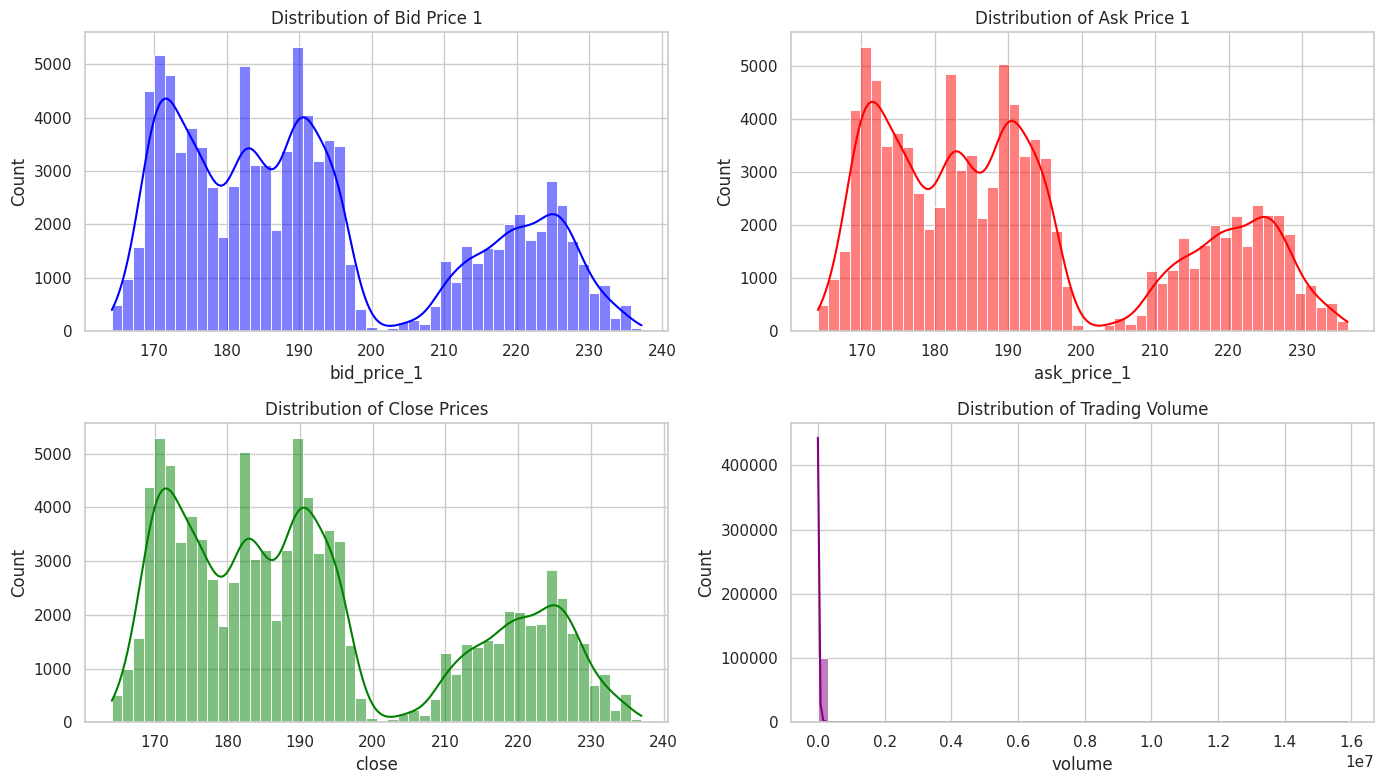

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Understand the Distribution of Key Features

# Set the plotting style
sns.set(style="whitegrid")

# Plotting the distribution of bid and ask prices
plt.figure(figsize=(14, 8))

# Distribution of bid prices
plt.subplot(2, 2, 1)
sns.histplot(merged_bid_ask_data['bid_price_1'], bins=50, kde=True, color='blue')
plt.title('Distribution of Bid Price 1')

plt.subplot(2, 2, 2)
sns.histplot(merged_bid_ask_data['ask_price_1'], bins=50, kde=True, color='red')
plt.title('Distribution of Ask Price 1')

# Plotting the distribution of OHLC prices
plt.subplot(2, 2, 3)
sns.histplot(merged_bid_ask_data['close'], bins=50, kde=True, color='green')
plt.title('Distribution of Close Prices')

plt.subplot(2, 2, 4)
sns.histplot(merged_bid_ask_data['volume'], bins=50, kde=True, color='purple')
plt.title('Distribution of Trading Volume')

# Show the plots
plt.tight_layout()
plt.show()


###Finding Correlations between features:


Private Variables:
- Remaining Inventory: To be maintained internally.
- Elapsed Time: Derived from timestamp.

Market Variables:

- Current Bid Price: bid_price_1.
- Current Ask Price: ask_price_1.
- Order Book Depth: bid_size_1 to bid_size_5, ask_size_1 to ask_size_5.
- Recent Trade Volume: volume.
- Market Order Submission Cost (Slippage): Derived from the difference between ask_price_1 and bid_price_1 (bid-ask spread).
- Price Changes (Volatility): volatility, log_return.

Additional Features:
- Time of Day: Derived from timestamp.
- Historical Price Data: open, high, low, close.


ValueError: could not convert string to float: '2023-09-12 13:45:00+00:00'

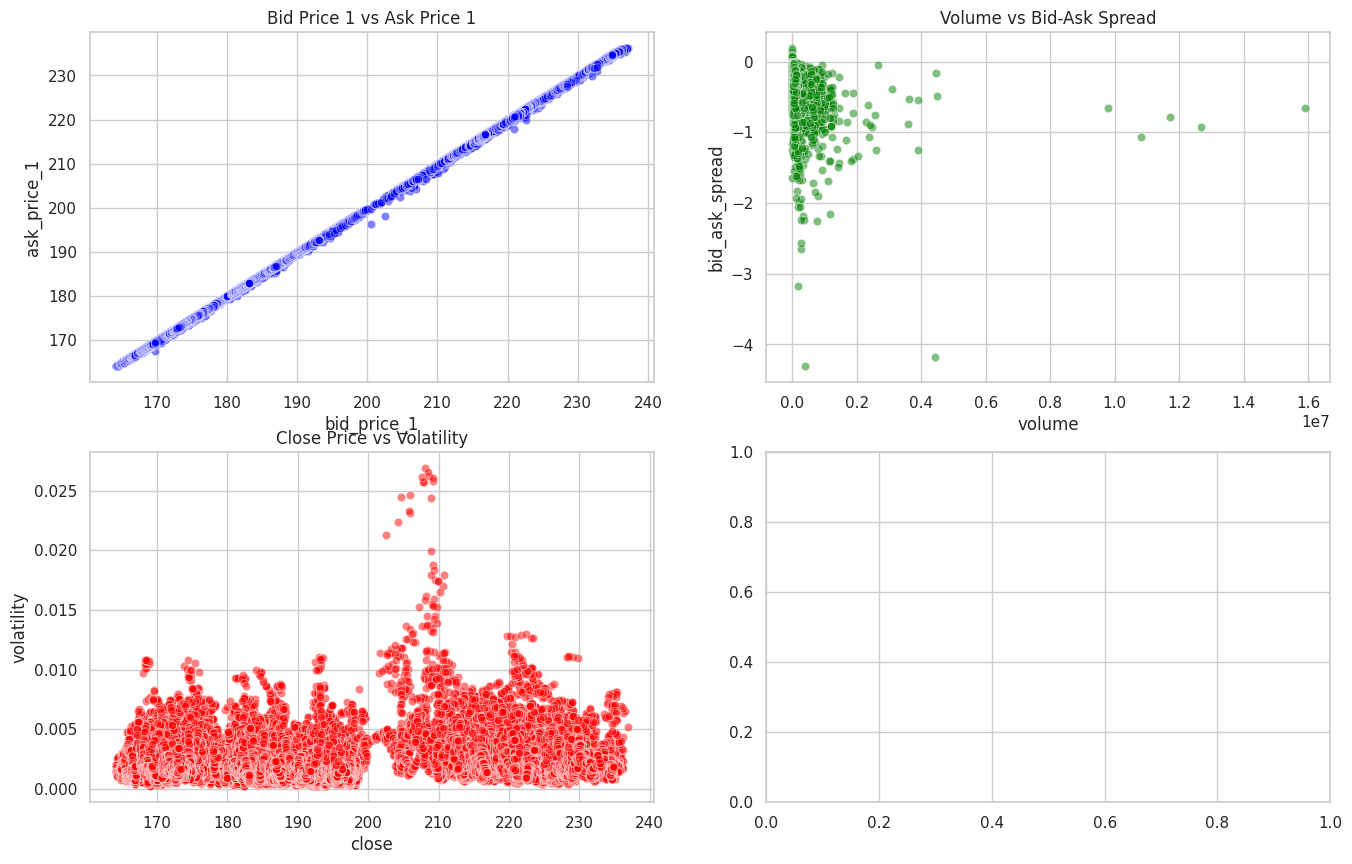

In [ ]:
# Step 2: Identify Relationships Between Key Features

# Compute the bid-ask spread as an additional feature
merged_bid_ask_data['bid_ask_spread'] = merged_bid_ask_data['ask_price_1'] - merged_bid_ask_data['bid_price_1']

# Plotting relationships between key features using scatter plots and correlation heatmap

plt.figure(figsize=(16, 10))

# Scatter plot: Bid Price 1 vs Ask Price 1
plt.subplot(2, 2, 1)
sns.scatterplot(data=merged_bid_ask_data, x='bid_price_1', y='ask_price_1', alpha=0.5, color='blue')
plt.title('Bid Price 1 vs Ask Price 1')

# Scatter plot: Volume vs Bid-Ask Spread
plt.subplot(2, 2, 2)
sns.scatterplot(data=merged_bid_ask_data, x='volume', y='bid_ask_spread', alpha=0.5, color='green')
plt.title('Volume vs Bid-Ask Spread')

# Scatter plot: Close Price vs Volatility
plt.subplot(2, 2, 3)
sns.scatterplot(data=merged_bid_ask_data, x='close', y='volatility', alpha=0.5, color='red')
plt.title('Close Price vs Volatility')

# Correlation heatmap for numerical features
plt.subplot(2, 2, 4)
sns.heatmap(merged_bid_ask_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Numerical Features')

# Show the plots
plt.tight_layout()
plt.show()


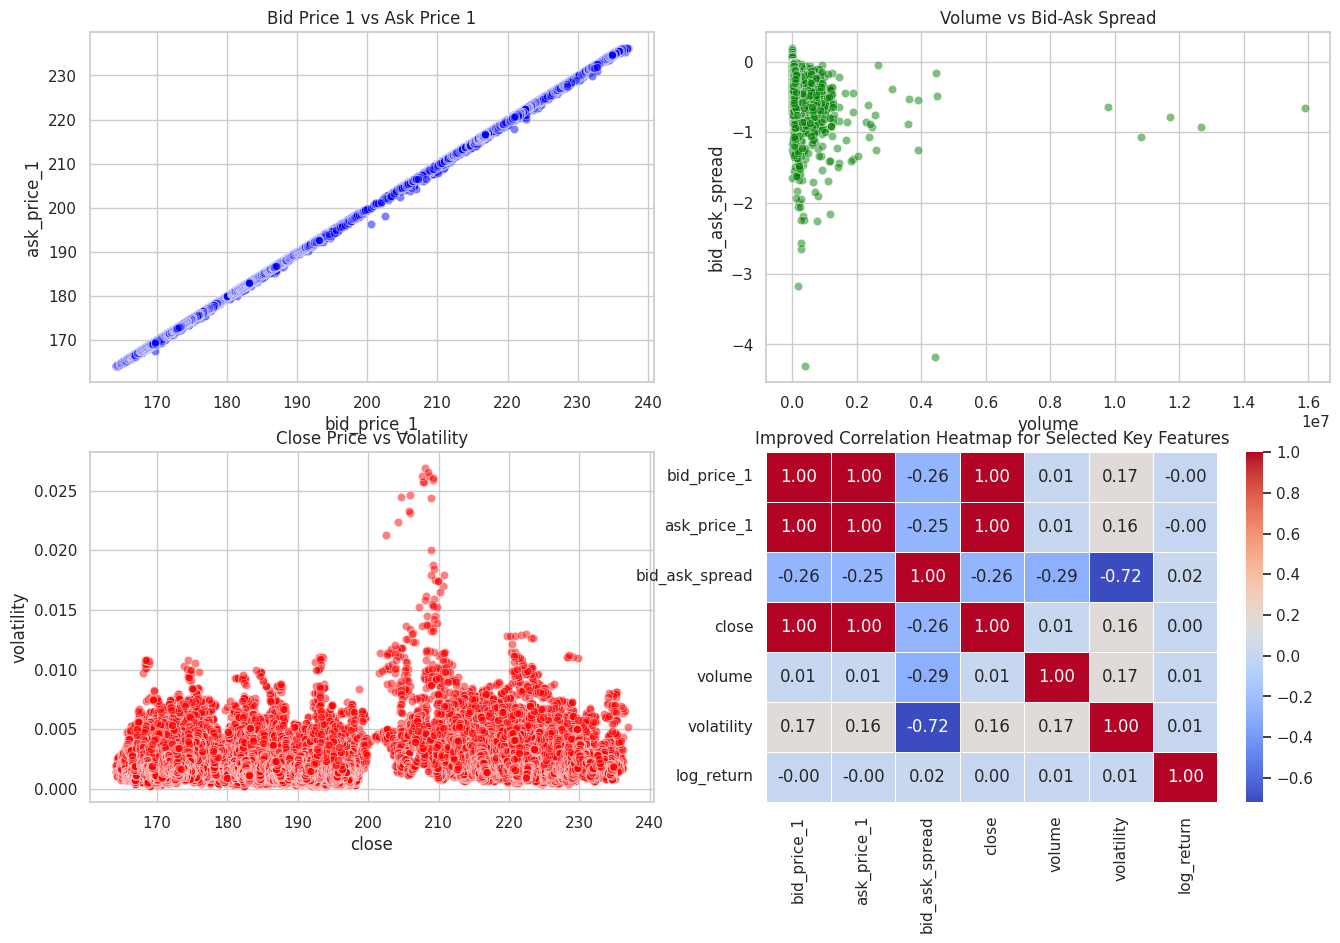

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Identify Relationships Between Key Features

# Compute the bid-ask spread as an additional feature
merged_bid_ask_data['bid_ask_spread'] = merged_bid_ask_data['ask_price_1'] - merged_bid_ask_data['bid_price_1']

# Plotting relationships between key features using scatter plots and correlation heatmap

plt.figure(figsize=(16, 10))

# Scatter plot: Bid Price 1 vs Ask Price 1
plt.subplot(2, 2, 1)
sns.scatterplot(data=merged_bid_ask_data, x='bid_price_1', y='ask_price_1', alpha=0.5, color='blue')
plt.title('Bid Price 1 vs Ask Price 1')

# Scatter plot: Volume vs Bid-Ask Spread
plt.subplot(2, 2, 2)
sns.scatterplot(data=merged_bid_ask_data, x='volume', y='bid_ask_spread', alpha=0.5, color='green')
plt.title('Volume vs Bid-Ask Spread')

# Scatter plot: Close Price vs Volatility
plt.subplot(2, 2, 3)
sns.scatterplot(data=merged_bid_ask_data, x='close', y='volatility', alpha=0.5, color='red')
plt.title('Close Price vs Volatility')

# Selecting a subset of key features to make the correlation heatmap more readable
key_features = ['bid_price_1', 'ask_price_1', 'bid_ask_spread', 'close', 'volume', 'volatility', 'log_return']

# Plotting the correlation heatmap for the selected features
plt.subplot(2, 2, 4)
sns.heatmap(merged_bid_ask_data[key_features].corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Improved Correlation Heatmap for Selected Key Features')
plt.show()

# Show the plots
plt.tight_layout()
plt.show()

###FEATURE ENGG

In [ ]:
# Step 3: Feature Engineering

# Creating additional features that will be useful for the RL model

# 1. Bid-Ask Spread (already calculated)
#    We've already created the 'bid_ask_spread' feature during EDA.

# 2. Rolling Moving Averages
#    Calculate short-term and long-term moving averages for the close price to capture trends
merged_bid_ask_data['ma_short'] = merged_bid_ask_data['close'].rolling(window=5).mean()  # Short-term (5-minute) moving average
merged_bid_ask_data['ma_long'] = merged_bid_ask_data['close'].rolling(window=20).mean()  # Long-term (20-minute) moving average

# 3. Rolling Standard Deviation (Volatility)
#    Calculate the rolling standard deviation to capture recent volatility
merged_bid_ask_data['rolling_volatility'] = merged_bid_ask_data['close'].rolling(window=10).std()

# 4. Time of Day Feature
#    Extract hour and minute from the timestamp to represent the time of day
merged_bid_ask_data['hour'] = pd.to_datetime(merged_bid_ask_data['timestamp']).dt.hour
merged_bid_ask_data['minute'] = pd.to_datetime(merged_bid_ask_data['timestamp']).dt.minute

# Drop any rows that may have NaN values due to rolling calculations
merged_bid_ask_data.dropna(inplace=True)

# Display the first few rows to review the new features
merged_bid_ask_data.head()

# Display the first few rows to review the new features
# import ace_tools as tools; tools.display_dataframe_to_user(name="Feature-Enhanced Dataset", dataframe=merged_bid_ask_data)


,timestamp,bid_price_1,bid_price_2,bid_price_3,bid_price_4,bid_price_5,bid_size_1,bid_size_2,bid_size_3,bid_size_4,...,volume,symbol,log_return,volatility,bid_ask_spread,ma_short,ma_long,rolling_volatility,hour,minute
72,2023-09-12 14:42:00+00:00,176.95,176.95,176.94,176.94,176.94,20000.0,20000.0,49300.0,49300.0,...,50132.0,AAPL,-0.000735,0.002991,-0.28,176.952,177.4330,0.265248,14,42
73,2023-09-12 14:43:00+00:00,176.84,176.83,176.83,176.83,176.83,17000.0,3900.0,20900.0,34900.0,...,19329.0,AAPL,-0.000226,0.002993,-0.15,176.890,177.3565,0.210671,14,43
74,2023-09-12 14:44:00+00:00,176.89,176.89,176.89,176.89,176.89,22500.0,23700.0,20000.0,41700.0,...,35107.0,AAPL,0.000453,0.003092,-0.25,176.842,177.2925,0.170036,14,44
75,2023-09-12 14:45:00+00:00,176.81,176.81,176.81,176.81,176.81,14000.0,4000.0,12500.0,2500.0,...,22940.0,AAPL,-0.000792,0.003134,-0.16,176.766,177.2275,0.191221,14,45
76,2023-09-12 14:46:00+00:00,176.80,176.80,176.80,176.80,176.80,88600.0,14100.0,10000.0,14000.0,...,22813.0,AAPL,0.000283,0.003184,-0.17,176.730,177.1740,0.182468,14,46


**Newly Created Features:**
- Bid-Ask Spread (bid_ask_spread): Calculated as the difference between the current best ask and bid prices.

- Short-Term Moving Average (ma_short): A 5-minute moving average of the close price to capture short-term trends.

- Long-Term Moving Average (ma_long): A 20-minute moving average of the close price to capture longer trends.

- Rolling Volatility (rolling_volatility): A 10-minute rolling standard deviation of the close price to measure recent market volatility.

- Time of Day (hour and minute): Extracted the hour and minute from the timestamp to provide context for market dynamics during different times of the day.

In [ ]:
# Specify the file path where you want to save the CSV
file_path = '/content/drive/MyDrive/Projects/Blockhouse/Data/final_data.csv'

# Save the DataFrame to CSV
merged_bid_ask_data.to_csv(file_path, index=False)  # Set index=False to avoid saving the index